In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scienceplots

In [2]:
import os

data_dir = r'C:\Users\pyxuan\Code\cpp\fdt\results\raw\ARC_FULL'

pipe_load_profile_path = os.path.join(data_dir, 'pipe_load_profile.csv')
body_kinematics_path = os.path.join(data_dir, 'body_kinematics.csv')
contact_force_path = os.path.join(data_dir, 'contact_force.csv')
global_timeseries_path = os.path.join(data_dir, 'global_timeseries.csv')
joint_articulation_path = os.path.join(data_dir, 'joint_articulation.csv')

In [3]:
plt.style.use(["notebook", "grid"])

In [4]:
pipe_load_profile = pd.read_csv(pipe_load_profile_path)
pipe_load_profile_late = pipe_load_profile[pipe_load_profile['Time_s'] >= 7]

In [5]:
def classify_segment(idx):
    if 0 <= idx < 17:
        return "Horizontal"
    elif 17 <= idx < 43:
        return "Build-up"
    else:
        return "Vertical"

# Apply to both pipe_load_profile and pipe_load_profile_late
pipe_load_profile['Segment'] = pipe_load_profile['JointIdx'].apply(classify_segment)
pipe_load_profile_late['Segment'] = pipe_load_profile_late['JointIdx'].apply(classify_segment)

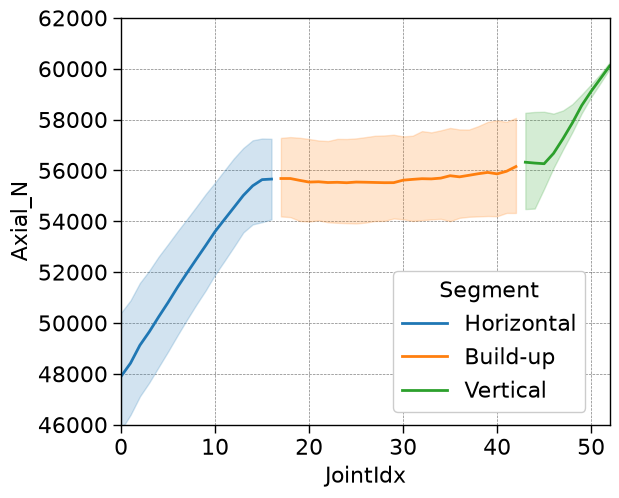

In [6]:
g = sns.relplot(
    data=pipe_load_profile_late,
    x="JointIdx",
    y="Axial_N",
    kind='line',
    errorbar=('pi', 90),
    estimator='median',
    hue='Segment',
    aspect=1.32 # 设置图表宽高比
)

# 获取当前绘图的 Axes 对象
ax = g.axes.flat[0]

# 启用顶部和右侧的边框 (spines)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

if g.legend is not None:
    g.legend.set_title("Segment")
    g.legend.set_bbox_to_anchor((0.7, 0.15))
    g.legend.set_loc("lower right")
    g.legend.set_frame_on(True)
    g.legend.get_frame().set_alpha(1.0)

# plt.xlabel("短节编号 (JointIdx)")
# plt.ylabel("轴向力 (Axial_N)")
plt.ylim(46000, 62000)
plt.xlim(0, 52)
plt.show()

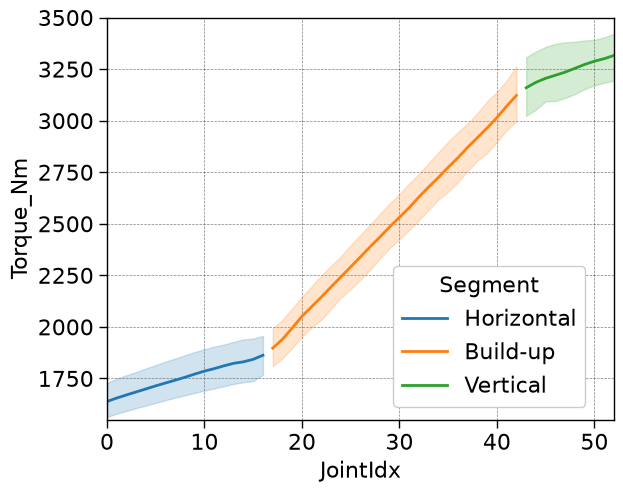

In [7]:
g = sns.relplot(
    data=pipe_load_profile_late,
    x="JointIdx",
    y="Torque_Nm",
    kind='line',
    errorbar=('pi', 90),
    estimator='median',
    hue='Segment',
    aspect=1.32 # 设置图表宽高比

)


# 获取当前绘图的 Axes 对象
ax = g.axes.flat[0]

# 启用顶部和右侧的边框 (spines)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

if g.legend is not None:
    g.legend.set_title("Segment")
    g.legend.set_bbox_to_anchor((0.7, 0.15))
    g.legend.set_loc("lower right")
    g.legend.set_frame_on(True)
    g.legend.get_frame().set_alpha(1.0)

# plt.xlabel("短节编号 (JointIdx)")
# plt.ylabel("轴向力 (Axial_N)")
plt.ylim(1550, 3500)
plt.xlim(0, 52)

plt.show()

In [8]:
joint_articulation_df = pd.read_csv(joint_articulation_path)
joint_articulation_df_late = joint_articulation_df[joint_articulation_df['Time_s'] >= 7]

joint_articulation_df['Segment'] = joint_articulation_df['JointIdx'].apply(classify_segment)
joint_articulation_df_late['Segment'] = joint_articulation_df_late['JointIdx'].apply(classify_segment)

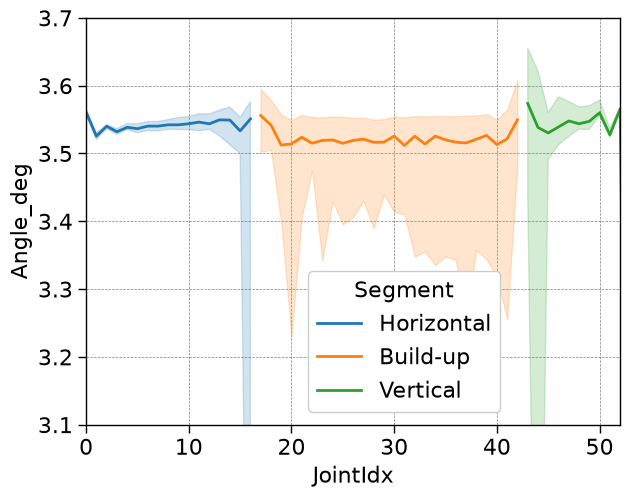

In [9]:
g = sns.relplot(
    data=joint_articulation_df_late,
    x="JointIdx",
    y="Angle_deg",
    kind='line',
    errorbar=('pi', 90),
    estimator='median',
    hue='Segment',
    aspect=1.32 # 设置图表宽高比
)

# 获取当前绘图的 Axes 对象
ax = g.axes.flat[0]

# 启用顶部和右侧的边框 (spines)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

if g.legend is not None:
    g.legend.set_title("Segment")
    g.legend.set_bbox_to_anchor((0.6, 0.15))
    g.legend.set_loc("lower right")
    g.legend.set_frame_on(True)
    g.legend.get_frame().set_alpha(1.0)

plt.ylim(3.1, 3.7)
plt.xlim(0, 52)
plt.show()

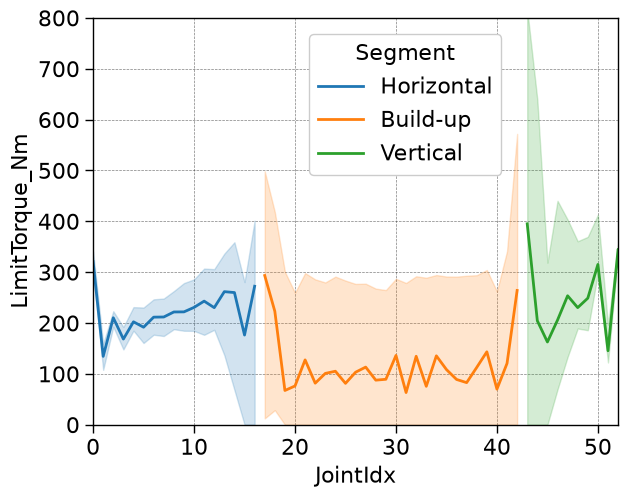

In [10]:
g = sns.relplot(
    data=joint_articulation_df_late,
    x="JointIdx",
    y="LimitTorque_Nm",
    kind='line',
    errorbar=('pi', 90),
    estimator='median',
    hue='Segment',
    aspect=1.32 # 设置图表宽高比
)

# 获取当前绘图的 Axes 对象
ax = g.axes.flat[0]

# 启用顶部和右侧的边框 (spines)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

if g.legend is not None:
    g.legend.set_title("Segment")
    g.legend.set_bbox_to_anchor((0.35, 0.95))
    g.legend.set_loc("upper left")
    g.legend.set_frame_on(True)
    g.legend.get_frame().set_alpha(1.0)

plt.ylim(0, 800)
plt.xlim(0, 52)
plt.show()